# Confidence Intervals - Interval Estimation 💡
In this notebook, we will learn how to calculate confidence intervals using two different methods:
- Using **Bootstrapping**
- Using **Z-Value** Formula

## Learning Objectives

At the end of this notebook, you should be able to:

- Construct a bootstrap confidence interval for the median taxi trip duration.
- Explain which factors change the width of a confidence interval.
- Construct a confidence interval with the z-value formula and with statsmodels, and compare the results.

This is an optional deep-dive. For the foundation see [`../1_population_vs_sample.ipynb`](../1_population_vs_sample.ipynb) and for the worked method see [`../2_ci_guide.ipynb`](../2_ci_guide.ipynb).


## What does Confidence Interval (CI) mean?
A **Confidence Interval** is a range of values that likely contains the true population parameter. It is calculated from a sample statistic and provides an **estimate of the uncertainty** associated with that statistic. The width of the confidence interval reflects the level of uncertainty: a **wider interval** indicates **more uncertainty**, while a **narrower interval** indicates **less uncertainty**.

The key components of a confidence interval are:
- **Point Estimate**: The sample statistic used to estimate the population parameter (e.g., sample mean).
- **Margin of Error**: The amount added and subtracted from the point estimate to create the interval.
- **Confidence Level**: It is a measure of certainty that a particular population parameter lies within a specific range. It is usually expressed as 



## Define CI using Bootstrap Sampling 🧳

<img src="../assets/bootstrap.png" alt="Bootstrapping" width="600"/>

**Bootstrap sampling** is a resampling technique that involves repeatedly drawing samples (with replacement) from an original dataset. This allows us to create multiple **"bootstrap" samples**, which can be used to estimate the **sampling distribution** of a statistic and calculate **confidence intervals**.

### Case Study 1 - Estimate the median of taxi trip duration in New York City
Our goal is to estimate the median of taxi trip duration in New York City using bootstrapping. 
We will use the `nyc_taxi` dataset, which contains information about taxi trips in New York City. 

**Columns in the dataset**:
- `pickup`: The date and time when the taxi trip started.
- `dropoff`: The date and time when the taxi trip ended.
- `passenger`: The number of passengers in the taxi.
- `distance`: The distance of the taxi trip in miles.
- `fare`: The fare of the taxi trip in dollars.
- `tip`: The tip given to the taxi driver in dollars.
- `tolls`: The tolls paid during the taxi trip in dollars.
- `total`: The total amount paid for the taxi trip in dollars.
- `color`: The color of the taxi.
- `payment`: The payment method used for the taxi trip.
- `pickup_zone`: The pickup zone of the taxi trip.
- `dropoff_zone`: The dropoff zone of the taxi trip.
- `pickup_borough`: The borough where the pickup zone is located.
- `dropoff_borough`: The borough where the dropoff zone is located.

**Why we use median?**
- Most likely the distribution of taxi trip duration is skewed, so the median is a better measure of central tendency than the mean.

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# Let's load the taxis dataset
taxis = sns.load_dataset("taxis")
taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [5]:
# Let's create a duration column
taxis["duration"] = taxis["dropoff"] - taxis["pickup"]
# Convert duration to minutes
taxis["duration_(m)"] = taxis["duration"].dt.total_seconds() / 60
taxis["duration_(m)"] = taxis["duration_(m)"]
taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,duration,duration_(m)
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,0 days 00:06:15,6.250000
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,0 days 00:07:05,7.083333
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,0 days 00:07:24,7.400000
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,0 days 00:25:52,25.866667
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,0 days 00:09:32,9.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,0 days 00:03:34,3.566667
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,0 days 00:56:23,56.383333
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn,0 days 00:19:07,19.116667
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,0 days 00:05:04,5.066667


#### How is the Trip Duration distributed?

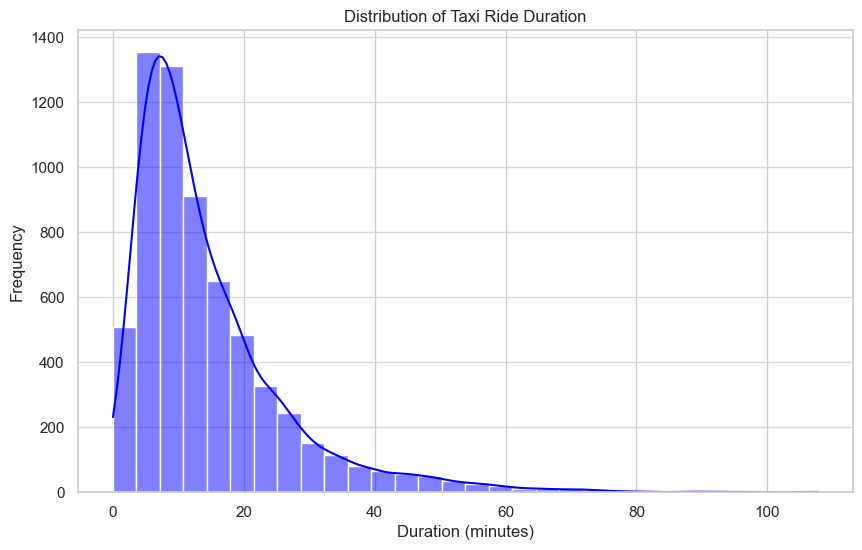

In [6]:
# Let's plot the duration of the taxi rides
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(taxis["duration_(m)"], bins=30, kde=True, color="blue")
plt.title("Distribution of Taxi Ride Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

As you can see, the distribution of taxi ride durations is right-skewed, with most rides being relatively short. The mean is likely to be pulled up by the long rides, while the median is a better measure of central tendency for this distribution.

In [7]:
# Let's calculate mean, median and mode
mean_duration = taxis["duration_(m)"].mean()
median_duration = taxis["duration_(m)"].median()
mode_duration = taxis["duration_(m)"].mode()[0]
print(f"Mean Duration: {mean_duration} minutes")
print(f"Median Duration: {median_duration} minutes")
print(f"Mode Duration: {mode_duration} minutes")

Mean Duration: 14.349616560443545 minutes
Median Duration: 10.9 minutes
Mode Duration: 5.416666666666667 minutes


In [8]:
# Let's calculate range, variance and standard deviation
range_duration = taxis["duration_(m)"].max() - taxis["duration_(m)"].min()
variance_duration = taxis["duration_(m)"].var()
std_dev_duration = taxis["duration_(m)"].std(ddof=1)
print(f"Range Duration: {range_duration} minutes")
print(f"Variance Duration: {variance_duration} minutes^2")
print(f"Standard Deviation Duration: {std_dev_duration} minutes")

Range Duration: 107.66666666666667 minutes
Variance Duration: 135.5802194148639 minutes^2
Standard Deviation Duration: 11.643891935897718 minutes


#### Step 1: Create Bootstrap Samples
We will create 10000 bootstrap samples with a sample size that is equal to a fraction of the original dataset. Each bootstrap sample will be created by randomly sampling with replacement from the original dataset. We will then calculate the median for each bootstrap sample and store the results in a list.

In [9]:
# Let's estimate the median duration using bootstrapping
n_iterations = 10000
bootstrapped_medians = []
for _ in range(n_iterations):
    sample = taxis["duration_(m)"].sample(frac=0.5, replace=True)
    bootstrapped_medians.append(sample.median())

#### Step 2: Calculate the Confidence Interval
The confidence level depends on the desired level of certainty. A 95% confidence level is commonly used in practice, but other levels (e.g., 90%, 99%) can also be used depending on the context and requirements of the analysis. 

We will calculate the 95% confidence interval for the median using the bootstrap samples. The confidence interval will be calculated by taking the 2.5th and 97.5th percentiles of the bootstrap medians. 



In [10]:
# Let's calculate the 95% confidence interval for the median duration
confidence_level = 0.95

quantile_2_5 = (1 - confidence_level) / 2
quantile_97_5 = 1 - quantile_2_5
# Let's calculate the confidence interval
lower_bound = pd.Series(bootstrapped_medians).quantile(q=quantile_2_5)
upper_bound = pd.Series(bootstrapped_medians).quantile(q=quantile_97_5)

print(
    f"{confidence_level * 100}% CI for the Median Taxi Duration: ({lower_bound}, {upper_bound}) minutes"
)

95.0% CI for the Median Taxi Duration: (10.5, 11.25) minutes


In [11]:
# We can embed everything in a function


def ci_bootstrap(data, n_iterations=10000, bootstripe_size=0.1, conf_level=0.95):
    """
    Function to calculate the confidence interval for the median using bootstrapping.

    Parameters:
    data (pd.Series): The data to bootstrap
    n_iterations (int): Number of bootstrap iterations
    bootstripe_size (float): Size of the bootstrap sample as a fraction of the original data
    conf_level (float): Confidence level for the interval

    Returns:
    tuple: Lower upper bounds of the confidence interval, and the list of bootstrapped medians
    """

    # Create an empty list to store the bootstrapped medians
    bootstrapped_medians = []

    # Perform bootstrapping
    for _ in range(n_iterations):
        sample = data.sample(frac=bootstripe_size, replace=True)
        bootstrapped_medians.append(sample.median())

    # Calculate the confidence interval
    lower_bound = pd.Series(bootstrapped_medians).quantile((1 - conf_level) / 2)
    upper_bound = pd.Series(bootstrapped_medians).quantile(1 - ((1 - conf_level) / 2))

    return lower_bound, upper_bound, bootstrapped_medians

In [12]:
conf_level = 0.95
lower_bound, upper_bound, bootstrapped_medians = ci_bootstrap(
    taxis["duration_(m)"],
    n_iterations=10000,
    bootstripe_size=0.1,
    conf_level=conf_level,
)
print(
    f"{conf_level * 100}% CI for the Median Taxi Duration: ({lower_bound}, {upper_bound}) minutes"
)

95.0% CI for the Median Taxi Duration: (10.116666666666667, 11.75) minutes


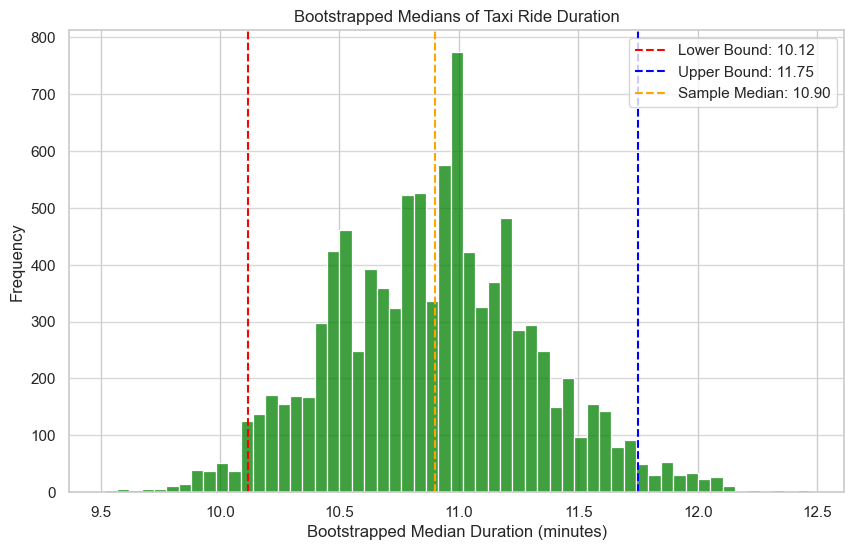

In [13]:
# Let's plot the bootstrapped medians
plt.figure(figsize=(10, 6))
sns.histplot(
    bootstrapped_medians,
    color="green",
)
# Add vertical lines for confidence interval
plt.axvline(
    lower_bound, color="red", linestyle="--", label=f"Lower Bound: {lower_bound:.2f}"
)
plt.axvline(
    upper_bound, color="blue", linestyle="--", label=f"Upper Bound: {upper_bound:.2f}"
)
plt.axvline(
    median_duration,
    color="orange",
    linestyle="--",
    label=f"Sample Median: {median_duration:.2f}",
)
plt.title("Bootstrapped Medians of Taxi Ride Duration")
plt.xlabel("Bootstrapped Median Duration (minutes)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.legend()
plt.show()

In [15]:
bootstraps_sizes = [0.01, 0.1, 0.4, 1.0]
conf_level = 0.95
for size in bootstraps_sizes:
    lower_bound, upper_bound, _ = ci_bootstrap(
        taxis["duration_(m)"],
        n_iterations=10000,
        bootstripe_size=size,
        conf_level=conf_level,
    )
    print(
        f"Bootstrap Size: {size}, {conf_level * 100}% CI for the Median Taxi Duration: ({round(lower_bound, 2)}, {round(upper_bound, 2)}) minutes"
    )

Bootstrap Size: 0.01, 95.0% CI for the Median Taxi Duration: (8.66, 13.8) minutes
Bootstrap Size: 0.1, 95.0% CI for the Median Taxi Duration: (10.12, 11.73) minutes
Bootstrap Size: 0.4, 95.0% CI for the Median Taxi Duration: (10.47, 11.3) minutes
Bootstrap Size: 1.0, 95.0% CI for the Median Taxi Duration: (10.62, 11.15) minutes


#### Which Insights can we draw from the CI?
- The **true median** of taxi trip duration in New York City is likely to be between 10.12 and 11.73 minutes with 95% confidence. This means that if we were to take many samples and calculate the CI for each sample,  
approximately 95% of those intervals would contain the true population median.
- The **bootstrap distribution** of the median is quite symmetrical, and the confidence interval is relatively narrow. This suggests that the median is a robust estimate of the central tendency of the taxi ride durations, even in the presence of outliers.



#### Which factors can affect the CI?
- **Sample Size**: A larger sample size will generally lead to a narrower confidence interval, as it provides more information about the population.
- **Confidence Level**: A higher confidence level (e.g., 99% vs. 95%) will result in a wider confidence interval, as it requires more certainty about the estimate.


#### Why do we use Bootstrapping?
- We don't need to make any assumptions about the population distribution.
  - Unknown distribution
  - Unknown parameters
- It can be applied to any statistic, not just the mean.
- It can be used for small sample sizes.
- It can be used for complex statistics, such as regression coefficients or machine learning model parameters.

### Case Study 2 - Modeling taxi trip duration given the distance
In this case study, we will use the `nyc_taxi` dataset to build a linear regression model to predict taxi trip duration based on the distance of the trip. We will then calculate the confidence intervals for the model coefficients using bootstrapping. 

We will use the BaggingRegressor from the `sklearn` library to create a bootstrap ensemble model. The BaggingRegressor will create multiple bootstrap samples and fit a linear regression model to each sample. We will then calculate the confidence intervals for the model coefficients using the bootstrap samples.

As a linear regression model, we will use the `HuberRegressor` from the `sklearn` library. The HuberRegressor is a robust linear regression model that is less sensitive to outliers than ordinary least squares regression. It uses a loss function that is less affected by extreme values, making it a good choice for datasets with outliers.

In [16]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import HuberRegressor

In [17]:
# Let's define the training data
df_train = taxis.copy()
# Let's define the features and target variable
X_train = df_train[["distance"]]
y_train = df_train["duration_(m)"]

In [18]:
# Let's define the model
huber_model = HuberRegressor(max_iter=1000, epsilon=1.6)

**$\epsilon$** is the threshold parameter that determines the sensitivity of the Huber loss function to outliers. The Huber loss function is defined as follows:
$$
L(y, f(x)) = \begin{cases}
\frac{1}{2}(y - f(x))^2 & \text{if } |y - f(x)| \leq \epsilon \\
\epsilon \cdot (|y - f(x)| - \frac{1}{2}\epsilon) & \text{otherwise}
\end{cases}
$$
where:
- $y$ is the true value
- $f(x)$ is the predicted value
- $\epsilon$ is the threshold parameter
- The Huber loss function is quadratic for small errors (when the absolute error is less than $\epsilon$) and linear for large errors (when the absolute error is greater than $\epsilon$). This makes it less sensitive to outliers than the ordinary least squares loss function, which is quadratic for all errors.

In [19]:
# Create the ensemble model
# Using Bagging with Huber Regressor as the base estimator
bagging_model = BaggingRegressor(
    estimator=huber_model,
    n_estimators=10000,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
)

In [20]:
# Let's fit the model
bagging_model.fit(X_train, y_train)

,estimator,HuberRegresso...max_iter=1000)
,n_estimators,10000
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,None
,verbose,0


In [21]:
# Get each model's parametres
model_coefs = [estimator.coef_[0] for estimator in bagging_model.estimators_]
model_intercepts = [estimator.intercept_ for estimator in bagging_model.estimators_]

In [22]:
model_coefs_df = pd.DataFrame(model_coefs, columns=["coef"])
model_intercepts_df = pd.DataFrame(model_intercepts, columns=["intercept"])

In [23]:
# Let's get the confidence intervals for the coefficients
conf_level = 0.95

quantile_2_5 = (1 - confidence_level) / 2
quantile_97_5 = 1 - quantile_2_5
# Let's get the lower and upper bounds for the coefficients
lower_bound_coef = model_coefs_df["coef"].quantile(q=quantile_2_5)
upper_bound_coef = model_coefs_df["coef"].quantile(q=quantile_97_5)
print(
    f"{conf_level * 100}% CI for the Coefficient: ({round(lower_bound_coef, 2)}, {round(upper_bound_coef, 2)})"
)

95.0% CI for the Coefficient: (2.55, 2.76)


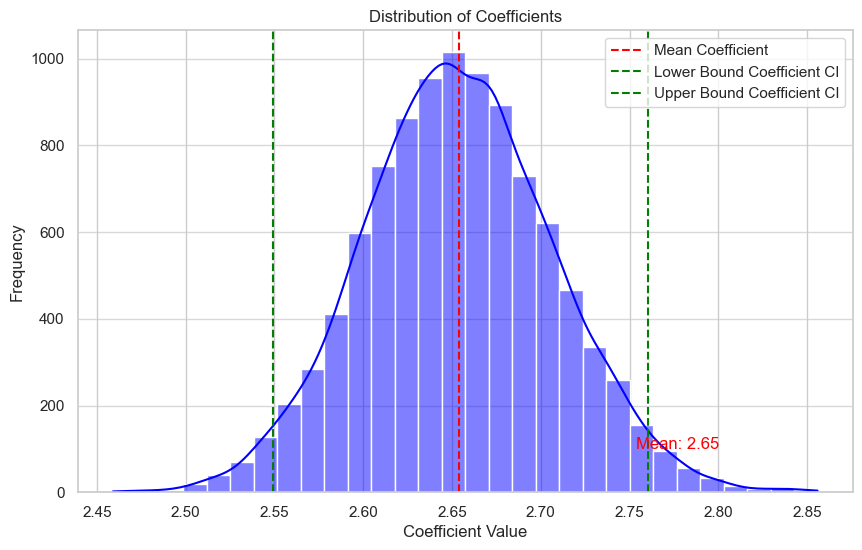

In [24]:
# Let's plot the distribution of the coefficients
plt.figure(figsize=(10, 6))
sns.histplot(model_coefs_df["coef"], bins=30, kde=True, color="blue")
# add a vertical line for the mean
plt.axvline(
    model_coefs_df["coef"].mean(), color="red", linestyle="--", label="Mean Coefficient"
)
# add a vertical line for the confidence interval
plt.axvline(
    lower_bound_coef, color="green", linestyle="--", label="Lower Bound Coefficient CI"
)
plt.axvline(
    upper_bound_coef, color="green", linestyle="--", label="Upper Bound Coefficient CI"
)
# add text for the mean
plt.text(
    model_coefs_df["coef"].mean() + 0.1,
    100,
    f"Mean: {model_coefs_df['coef'].mean():.2f}",
    color="red",
)
plt.title("Distribution of Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.legend()
plt.show()

In [25]:
# let's get the confidence intervals for the intercepts
conf_level = 0.95
quantile_2_5 = (1 - confidence_level) / 2
quantile_97_5 = 1 - quantile_2_5
# Let's get the lower and upper bounds for the intercepts
lower_bound_intercept = model_intercepts_df["intercept"].quantile(q=quantile_2_5)
upper_bound_intercept = model_intercepts_df["intercept"].quantile(q=quantile_97_5)
print(
    f"{conf_level * 100}% CI for the Intercept: ({round(lower_bound_intercept, 2)}, {round(upper_bound_intercept, 2)})"
)

95.0% CI for the Intercept: (5.58, 6.04)


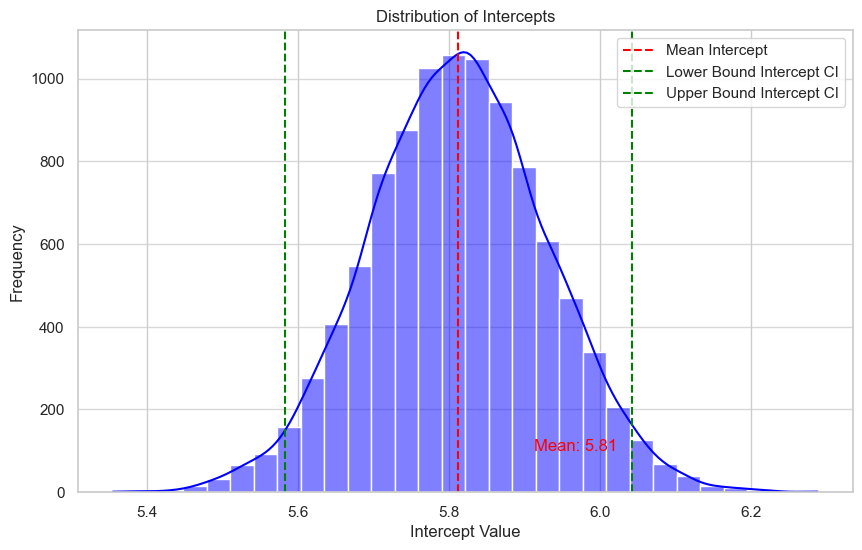

In [26]:
# Let's plot the distribution of the intercepts
plt.figure(figsize=(10, 6))
sns.histplot(model_intercepts_df["intercept"], bins=30, kde=True, color="blue")
# add a vertical line for the mean
plt.axvline(
    model_intercepts_df["intercept"].mean(),
    color="red",
    linestyle="--",
    label="Mean Intercept",
)
# add a vertical line for the confidence interval
plt.axvline(
    lower_bound_intercept,
    color="green",
    linestyle="--",
    label="Lower Bound Intercept CI",
)
plt.axvline(
    upper_bound_intercept,
    color="green",
    linestyle="--",
    label="Upper Bound Intercept CI",
)
# add text for the mean
plt.text(
    model_intercepts_df["intercept"].mean() + 0.1,
    100,
    f"Mean: {model_intercepts_df['intercept'].mean():.2f}",
    color="red",
)
plt.title("Distribution of Intercepts")
plt.xlabel("Intercept Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.legend()
plt.show()

## Define CI using Z-Value Formula
In addition to bootstrapping, we can also calculate confidence intervals for the model coefficients using the **Z-value formula**. 
The **Z-Value** formula is based on the assumption that the sampling distribution of the coefficient estimates is **approximately normal**. This assumption is valid when the sample size is large enough (typically n > 30). This holds true because of the **Central Limit Theorem**. In case the sample size is small, the [t-distribution](https://en.wikipedia.org/wiki/Student%27s_t-distribution) should be used instead of the normal distribution. 

### Z-Value Formula
The Z-Value formula for calculating the confidence interval for a population mean is given by:
$$
CI = \bar{x} \pm z_{\alpha/2} \cdot SE
$$
where:
- $\bar{x}$ is the sample mean
- $z_{\alpha/2}$ is the [Z-value](https://conversion-uplift.co.uk/glossary-of-conversion-marketing/z-score/) for the desired confidence level (e.g., 1.96 for 95% confidence)
- $\alpha$ is the significance level, which is equal to 1 - confidence level. For example, for a 95% confidence level, $\alpha$ = 0.05.
- $SE$ is the standard error of the mean, calculated as:
$$
SE = \frac{\sigma}{\sqrt{n}}
$$
where:
- $\sigma$ is the population standard deviation (or sample standard deviation if the population standard deviation is unknown)
- $n$ is the sample size

## Bonus: Confidence Intervals using Statsmodels
The Statsmodels library calculates confidence intervals for linear regression models using the **Z-Value** formula.

In [27]:
# Huber Regressor from statsmodels
import statsmodels.api as sm

Xtrain = X_train.copy()
ytrain = y_train.copy()

In [28]:
# Let's add a constant to the model for the intercept
Xtrain_cos = sm.add_constant(Xtrain)
model = sm.RLM(ytrain, Xtrain_cos, M=sm.robust.norms.HuberT())

# Fit the model
results = model.fit()

# Print the model parameters and confidence intervals
print("Model Coefficient:")
print(results.params)
print()
print("Standard Errors:")
print(results.bse)
print()
print("Confidence Intervals:")
print(results.conf_int(alpha=0.05))  # 95% CI

Model Coefficient:
const       5.810167
distance    2.652568
dtype: float64

Standard Errors:
const       0.077238
distance    0.015833
dtype: float64

Confidence Intervals:
                 0         1
const     5.658784  5.961550
distance  2.621537  2.683599


In [29]:
# Let's get the full summary of the model
print()
print("Model Summary:")
results.summary()


Model Summary:


<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:           duration_(m)   No. Observations:                 6433
Model:                            RLM   Df Residuals:                     6431
Method:                          IRLS   Df Model:                            1
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 31 Jul 2025                                         
Time:                        13:14:40                                         
No. Iterations:                    33                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.8102      0.077     75.224      0.000       5.659       5.962
distance       2.6526      0.016    167.538      0.000       2.622       2.684
==============================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

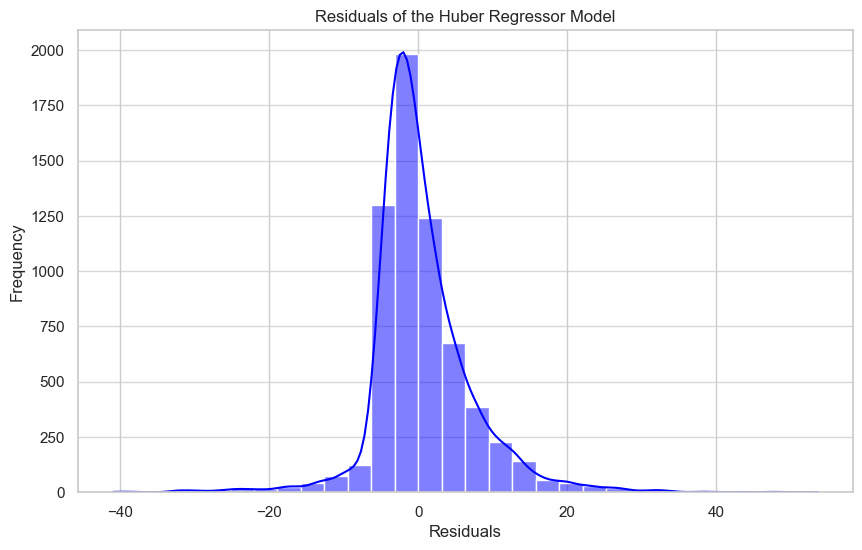

In [30]:
# Let's plot the residuals
plt.figure(figsize=(10, 6))
sns.histplot(results.resid, bins=30, kde=True, color="blue")
plt.title("Residuals of the Huber Regressor Model")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
# Let's plot the residuals vs fitted values
plt.show()

## Summary

In this notebook you:

- Built a bootstrap confidence interval for the median taxi trip duration.
- Examined which factors affect the width of a confidence interval.
- Compared the bootstrap interval with the z-value formula and a statsmodels calculation.

## References & Further Reading

- [**Confidence Intervals Guide**](../2_ci_guide.ipynb): The worked method this deep-dive extends.
- [**scipy.stats reference**](https://docs.scipy.org/doc/scipy/reference/stats.html): The distribution functions used here.
- [**seaborn: the taxis dataset**](https://seaborn.pydata.org/generated/seaborn.load_dataset.html): The built-in dataset loaded in this notebook.
